In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import data.d_load

bt, at = data.d_load.load()

In [3]:
bt

,update_id,best_bid_price,best_bid_qty,best_ask_price,best_ask_qty,transaction_time,event_time
0,4264349177374,64020.3,1.790,64020.4,3.636,1711238400018,1711238400024
1,4264349179250,64020.3,1.790,64020.4,3.634,1711238400033,1711238400039
2,4264349179655,64020.3,1.790,64020.4,3.640,1711238400037,1711238400044
3,4264349181766,64020.3,2.002,64020.4,3.640,1711238400049,1711238400058
4,4264349184343,64020.3,2.052,64020.4,3.640,1711238400064,1711238400073
...,...,...,...,...,...,...,...
91449742,4312569098807,69642.0,0.660,69642.1,3.074,1711843199631,1711843199637
91449743,4312569103997,69642.0,0.660,69642.1,3.071,1711843199735,1711843199741
91449744,4312569105328,69642.0,0.660,69642.1,3.074,1711843199775,1711843199780
91449745,4312569109173,69642.0,0.660,69642.1,3.076,1711843199878,1711843199885


In [4]:
at

,agg_trade_id,price,quantity,first_trade_id,last_trade_id,transact_time,is_buyer_maker
0,2096641851,64020.4,3.194,4790419953,4790419970,1711238400088,False
1,2096641852,64021.2,0.003,4790419971,4790419971,1711238400094,False
2,2096641853,64022.0,0.002,4790419972,4790419972,1711238400094,False
3,2096641854,64022.2,0.004,4790419973,4790419973,1711238400094,False
4,2096641855,64023.8,0.004,4790419974,4790419974,1711238400095,False
...,...,...,...,...,...,...,...
10893227,2107535078,69642.2,0.009,4817720262,4817720262,1711843198883,True
10893228,2107535079,69642.1,0.258,4817720263,4817720263,1711843198883,True
10893229,2107535080,69642.0,0.238,4817720264,4817720265,1711843198883,True
10893230,2107535081,69642.1,0.220,4817720266,4817720267,1711843198941,False


In [5]:
import params.sigma

mid, deduped = params.sigma.build_mid(bt)
rolling_sigma = params.sigma.estimate_rolling_vol(mid)
ewma_sigma = params.sigma.estimate_ewma_vol(mid)

rolling_sigma = params.sigma.return_training_slice(rolling_sigma)
ewma_sigma = params.sigma.return_training_slice(ewma_sigma)

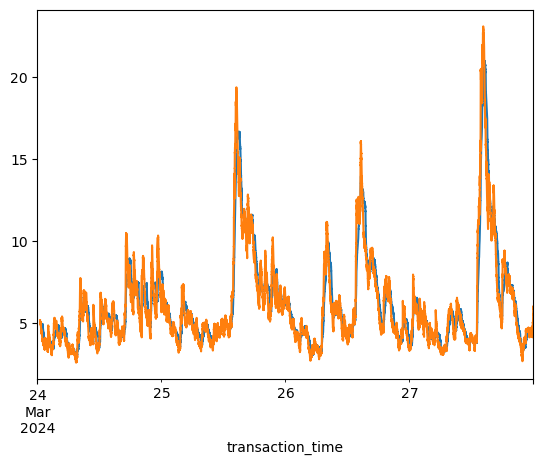

In [6]:
import matplotlib.pyplot as plt

rolling_sigma.plot()
ewma_sigma.plot()
plt.show()

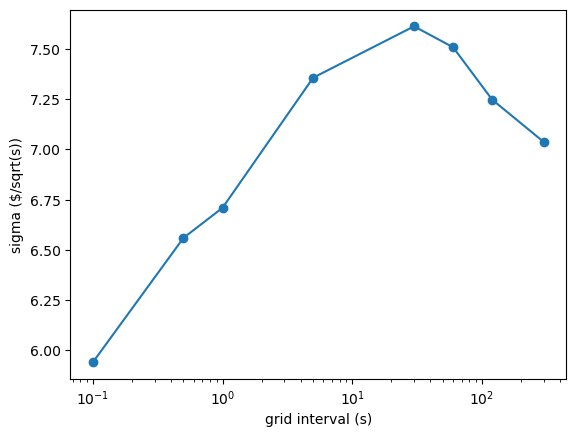

In [7]:
# tuning grid frequency

sigmas = params.sigma.return_grid_sigmas(bt)

x = [params.sigma.to_seconds(f) for f in sigmas.keys()]
y = list(sigmas.values())

plt.plot(x, y, marker = 'o')
plt.xscale('log')
plt.xlabel('grid interval (s)')
plt.ylabel('sigma ($/sqrt(s))')
plt.show()

In [65]:
import params.intensity

matched = params.intensity.match_trades(at, deduped)
matched = params.sigma.return_training_slice(matched)

In [54]:
matched

,price,quantity,is_buyer_maker,mid_price
transact_time,,,,
2024-03-24 00:00:00.088,64020.4,3.194,False,64020.35
2024-03-24 00:00:00.094,64021.2,0.003,False,64021.15
2024-03-24 00:00:00.094,64022.0,0.002,False,64021.15
2024-03-24 00:00:00.094,64022.2,0.004,False,64021.15
2024-03-24 00:00:00.095,64023.8,0.004,False,64023.75
...,...,...,...,...
2024-03-27 23:59:58.974,69532.6,0.007,True,69532.65
2024-03-27 23:59:59.078,69532.7,0.018,False,69532.65
2024-03-27 23:59:59.113,69532.6,0.014,True,69532.65


In [66]:
spreads = params.intensity.calculate_spread(matched)

<Axes: xlabel='transact_time'>

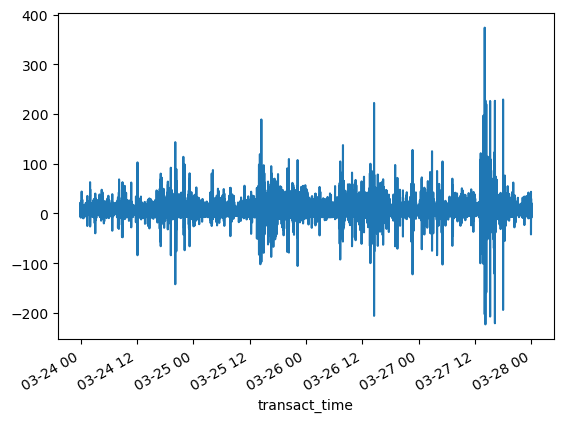

In [56]:
spreads['depth'].plot()

In [57]:
spreads['depth'].describe()

count    7.740801e+06
mean     3.958039e+00
std      1.051197e+01
min     -2.230500e+02
25%      5.000000e-02
50%      6.500000e-01
75%      3.450000e+00
max      3.736000e+02
Name: depth, dtype: float64

In [58]:
(spreads['depth'] < 0).mean()

np.float64(0.004643963848185737)

In [59]:
spreads

,price,quantity,is_buyer_maker,mid_price,depth
transact_time,,,,,
2024-03-24 00:00:00.088,64020.4,3.194,False,64020.35,0.05
2024-03-24 00:00:00.094,64021.2,0.003,False,64021.15,0.05
2024-03-24 00:00:00.094,64022.0,0.002,False,64021.15,0.85
2024-03-24 00:00:00.094,64022.2,0.004,False,64021.15,1.05
2024-03-24 00:00:00.095,64023.8,0.004,False,64023.75,0.05
...,...,...,...,...,...
2024-03-27 23:59:58.974,69532.6,0.007,True,69532.65,0.05
2024-03-27 23:59:59.078,69532.7,0.018,False,69532.65,0.05
2024-03-27 23:59:59.113,69532.6,0.014,True,69532.65,0.05


In [60]:
sample = spreads.loc[
    (spreads.index >= '2024-03-24 03:00:00') &
    (spreads.index <  '2024-03-24 03:01:00'),
    ['price', 'mid_price', 'is_buyer_maker', 'depth']
]
print(sample.head(10))

                           price  mid_price  is_buyer_maker  depth
transact_time                                                     
2024-03-24 03:00:00.016  64315.7   64315.65           False   0.05
2024-03-24 03:00:00.043  64315.6   64315.65            True   0.05
2024-03-24 03:00:00.186  64315.7   64315.65           False   0.05
2024-03-24 03:00:00.186  64315.9   64315.65           False   0.25
2024-03-24 03:00:00.389  64315.9   64315.85           False   0.05
2024-03-24 03:00:00.441  64316.4   64315.85           False   0.55
2024-03-24 03:00:00.441  64316.5   64315.85           False   0.65
2024-03-24 03:00:00.441  64316.7   64315.85           False   0.85
2024-03-24 03:00:00.441  64317.0   64315.85           False   1.15
2024-03-24 03:00:00.468  64317.2   64317.25            True   0.05


In [99]:
events = params.intensity.event_aggregation(spreads)

In [100]:
events

,max_depth,trade_quantity,is_buyer_maker,transact_time
event_id,,,,
1,0.05,3.194,False,2024-03-24 00:00:00.088
2,1.05,0.013,False,2024-03-24 00:00:00.094
3,0.05,0.019,False,2024-03-24 00:00:00.114
4,0.05,0.026,True,2024-03-24 00:00:00.150
5,0.05,0.032,False,2024-03-24 00:00:00.253
...,...,...,...,...
3296515,0.05,0.007,True,2024-03-27 23:59:58.974
3296516,0.05,0.018,False,2024-03-27 23:59:59.078
3296517,0.05,0.014,True,2024-03-27 23:59:59.113


In [101]:
sample = events.loc[
    (events['transact_time'] >= '2024-03-24 03:00:00') &
    (events['transact_time'] <  '2024-03-24 03:01:00'),
    ['max_depth', 'trade_quantity', 'is_buyer_maker', 'transact_time']
]
print(sample.head(10))

          max_depth  trade_quantity  is_buyer_maker           transact_time
event_id                                                                   
60175          0.05           0.021           False 2024-03-24 03:00:00.016
60176          0.05           0.020            True 2024-03-24 03:00:00.043
60177          0.25           0.012           False 2024-03-24 03:00:00.186
60178          0.05           0.134           False 2024-03-24 03:00:00.389
60179          1.15           0.048           False 2024-03-24 03:00:00.441
60180          0.05           0.130            True 2024-03-24 03:00:00.468
60181          0.05           0.010           False 2024-03-24 03:00:00.525
60182          7.15          10.000            True 2024-03-24 03:00:00.548
60183          0.05           0.022            True 2024-03-24 03:00:00.633
60184          0.05           0.014           False 2024-03-24 03:00:00.746


In [92]:
sample = spreads.loc[
    (spreads.index >= '2024-03-24 03:00:00') &
    (spreads.index <  '2024-03-24 03:00:00.5'),
    ['depth', 'quantity', 'is_buyer_maker', 'first_trade_id', 'last_trade_id']
]
sample

,depth,quantity,is_buyer_maker,first_trade_id,last_trade_id
transact_time,,,,,
2024-03-24 03:00:00.016,0.05,0.021,False,4790725713,4790725714
2024-03-24 03:00:00.043,0.05,0.020,True,4790725715,4790725715
2024-03-24 03:00:00.186,0.05,0.007,False,4790725716,4790725718
2024-03-24 03:00:00.186,0.25,0.005,False,4790725719,4790725720
2024-03-24 03:00:00.389,0.05,0.134,False,4790725721,4790725769
2024-03-24 03:00:00.441,0.55,0.004,False,4790725770,4790725772
2024-03-24 03:00:00.441,0.65,0.003,False,4790725773,4790725774
2024-03-24 03:00:00.441,0.85,0.004,False,4790725775,4790725776
2024-03-24 03:00:00.441,1.15,0.037,False,4790725777,4790725793
